# Installs

In [1]:
!python --version
!pip --version

Python 3.11.9
pip 26.1.2 from C:\Users\pesen\Documents\UCL Masters Coursework\Masters Project SWOT\swot_env\Lib\site-packages\pip (python 3.11)



In [9]:
!pip install xarray netCDF4 matplotlib

  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 14.8 MB/s  0:00:00
   ---------------------------------------- 0.0/21.3 MB ? eta -:--:--
   ------------------------------- -------- 16.5/21.3 MB 80.1 MB/s eta 0:00:01
   ---------------------------------------- 21.3/21.3 MB 67.2 MB/s  0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 9.3/9.3 MB 72.4 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 67.6 MB/s  0:00:00
Using cached packaging-26.2-py3-none-any.whl (100 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --------------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
podaac-data-subscriber 1.15.2 requires packaging<24.0,>=23.0, but you have packaging 26.2 which is incompatible.


# Data Download

## KaRIn data download for 01/01/2024

In [8]:
!podaac-data-downloader -c SWOT_L2_LR_SSH_D -d ./data/test_data_18Jun -sd 2024-01-01T00:00:00Z -ed 2024-01-02T00:00:00Z --limit 5

[2026-06-18 22:16:59,323] {podaac_data_downloader.py:146} INFO - NOTE: Making new data directory at ./data/test_data_18Jun(This is the first run.)
[2026-06-18 22:17:01,430] {podaac_data_downloader.py:317} INFO - Found 116 total files to download
[2026-06-18 22:17:01,430] {podaac_data_downloader.py:319} INFO - Limiting downloads to 5 total files
[2026-06-18 22:17:07,218] {podaac_data_downloader.py:358} INFO - 2026-06-18 22:17:07.218609 SUCCESS: https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_LR_SSH_D/SWOT_L2_LR_SSH_Basic_008_524_20240101T231609_20240102T000738_PGD0_02.nc
[2026-06-18 22:17:09,988] {podaac_data_downloader.py:358} INFO - 2026-06-18 22:17:09.987759 SUCCESS: https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_LR_SSH_D/SWOT_L2_LR_SSH_WindWave_008_524_20240101T231609_20240102T000738_PGD0_02.nc
[2026-06-18 22:17:13,325] {podaac_data_downloader.py:358} INFO - 2026-06-18 22:17:13.325603 SUCCESS: https:/

## Nadir data download for 01/01/2024

In [86]:
!podaac-data-downloader -c SWOT_L2_NALT_GDR_SSHA_2.0 -d ./data/nadir --start-date 2024-01-01T00:00:00Z --end-date 2024-01-02T00:00:00Z --limit 1

[2026-07-15 17:50:22,641] {podaac_data_downloader.py:317} INFO - Found 29 total files to download
[2026-07-15 17:50:22,641] {podaac_data_downloader.py:319} INFO - Limiting downloads to 1 total files
[2026-07-15 17:50:22,643] {podaac_data_downloader.py:350} INFO - 2026-07-15 17:50:22.643874 SKIPPED: https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_NALT_GDR_2.0/SWOT_GPR_2PfP008_524_20240101_231610_20240102_000737.nc
[2026-07-15 17:50:22,645] {podaac_data_downloader.py:350} INFO - 2026-07-15 17:50:22.645887 SKIPPED: https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_NALT_GDR_2.0/SWOT_GPR_2PfP008_523_20240101_222443_20240101_231610.nc
[2026-07-15 17:50:22,649] {podaac_data_downloader.py:350} INFO - 2026-07-15 17:50:22.649887 SKIPPED: https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_NALT_GDR_2.0/SWOT_GPR_2PfP008_522_20240101_213316_20240101_222443.nc
[2026-07-15 17:50:22,651

# Imports

In [2]:
from pathlib import Path

import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# Display

In [3]:
# Display configs
vmin = -0.2
vmax = 0.2

dot_size = 5

In [4]:
# cmap configs
cmap = 'RdBu_r'

# Create colour map (cmap) for graphs that plots NaN values as green
cmap_with_nan = plt.get_cmap(cmap).copy()
cmap_with_nan.set_bad(color='green')

In [5]:
def open_half_orbit(karin_or_nadir, file_name, display_xarray=False):
    
    if karin_or_nadir not in ['karin', 'nadir']:
        raise ValueError(f"Invalid argument: '{karin_or_nadir}'. Must be 'karin' or 'nadir'.")

    file_path = Path('./data') / karin_or_nadir / file_name

    if not file_path.exists():
        raise FileNotFoundError(f"Dataset not found at expected path: {file_path}")

    if karin_or_nadir == 'karin':
        ds = xr.open_dataset(file_path)
        if display_xarray:
            display(ds)

        ssha = (ds['ssha_karin_2'] + ds['height_cor_xover']).assign_coords(
            time=ds['time'],
            latitude=ds['latitude'],
            longitude=ds['longitude']
        )
    
    elif karin_or_nadir == 'nadir':
        ds = xr.open_dataset(file_path, group='data_01')
        if display_xarray:
            display(ds)

        ds_ku = xr.open_dataset(file_path, group='data_01/ku')
        if display_xarray:
            display(ds_ku)

        ssha = ds_ku['ssha'].assign_coords(
            time=ds['time'], 
            latitude=ds['latitude'], 
            longitude=ds['longitude']
        )

    return ssha

In [6]:
def display_nadir(ssha, dot_size=dot_size):
    time = ssha['time']
    lat = ssha['latitude']
    lon = ssha['longitude']

    flat_data = ssha.values.flatten()

    # Display graphs
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    t_min = pd.to_datetime(time.min().values).strftime('%Y-%m-%d %H:%M:%S')
    t_max = pd.to_datetime(time.max().values).strftime('%Y-%m-%d %H:%M:%S')
    fig.suptitle(f'SWOT Nadir SSHA from "{t_min}" to "{t_max}"')

    nan_mask = np.isnan(ssha)
    ax1.scatter(lon[nan_mask], lat[nan_mask], color='green', s=dot_size)
    sc = ax1.scatter(lon, lat, c=ssha, vmin=vmin, vmax=vmax, cmap=cmap, s=dot_size)
    fig.colorbar(sc, ax = ax1, label='SSHA (m)')
    ax1.set_title(f'SSHA plot   (NaN proportion: {np.isnan(flat_data).sum() / len(flat_data):.2%})')
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')

    ax2.hist(flat_data, bins=100, range=(-3000, 3000), color='teal', edgecolor='black', alpha=0.7)
    ax2.set_title(f'SSHA distribution')
    ax2.set_xlabel('SSHA (m)')
    ax2.set_ylabel('Pixel Count')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [7]:
def display_karin(ssha):
    time = ssha['time']

    flat_data = ssha.values.flatten()

    # Display graphs
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    t_min = pd.to_datetime(time.min().values).strftime('%Y-%m-%d %H:%M:%S')
    t_max = pd.to_datetime(time.max().values).strftime('%Y-%m-%d %H:%M:%S')
    fig.suptitle(f'SWOT Karin SSHA from "{t_min}" to "{t_max}"')

    ssha.plot(ax=ax1, cmap=cmap_with_nan, vmin=vmin, vmax=vmax)
    ax1.set_title(f'SSHA plot   (NaN proportion: {np.isnan(flat_data).sum() / len(flat_data):.2%})')

    ax2.hist(flat_data, bins=100, range=(-3000, 3000), color='teal', edgecolor='black', alpha=0.7)
    ax2.set_title(f'SSHA distribution')
    ax2.set_xlabel('SSHA (m)')
    ax2.set_ylabel('Pixel Count')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [8]:
valid_satellites = ['karin', 'nadir']

def display_satellite_tracks(satellite, start_time, end_time):
    
    # format into time for download

    # download data between sd and ed

    # 

SyntaxError: incomplete input (1768017787.py, line 9)

In [9]:
display(xr.open_dataset('./data/nadir/SWOT_GPR_2PfP008_524_20240101_231610_20240102_000737.nc'))

display(xr.open_dataset('./data/nadir/SWOT_GPR_2PfP008_524_20240101_231610_20240102_000737.nc', group='data_01'))
        
display(open_half_orbit('nadir', 'SWOT_GPR_2PfP008_524_20240101_231610_20240102_000737.nc'))

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/40)
    Conventions:                      CF-1.7
    title:                            GDR - Reduced dataset
    source:                           Processing Baseline F v1.04
    contact:                          CNES aviso@altimetry.fr, JPL podaac@pod...
    reference_document:               SWOT Nadir Altimeter Products Handbook,...
    mission_name:                     SWOT
    ...                               ...
    xref_utc_tai_data:                SMM_TUC_AXVCNE20161214_152427_19900101_...
    xref_gim_data:                    SWOT_ION_AXPCNE20240102_071118_20240101...
    xref_mog2d_data:                  SMM_MOG_AXVCNE20240122_070002_20240101_...
    xref_polar_ice_data:              SMM_ICN_AXPCNE20240117_100321_20240101_...
    ellipsoid_axis:                   6378137.0
    ellipsoid_flattening:             0.00335281066474748

<xarray.Dataset> Size: 606kB
Dimensions:                            (time: 2806)
Coordinates:
  * time                               (time) datetime64[ns] 22kB 2024-01-01T...
    latitude                           (time) float64 22kB ...
    longitude                          (time) float64 22kB ...
Data variables: (12/31)
    time_tai                           (time) datetime64[ns] 22kB ...
    surface_classification_flag        (time) float32 11kB ...
    rad_side_1_surface_type_flag       (time) float32 11kB ...
    rad_side_2_surface_type_flag       (time) float32 11kB ...
    alt_qual                           (time) float32 11kB ...
    rad_qual                           (time) float32 11kB ...
    ...                                 ...
    pole_tide                          (time) float64 22kB ...
    internal_tide_hret                 (time) float64 22kB ...
    wind_speed_alt                     (time) float64 22kB ...
    wind_speed_alt_mle3                (time) float64 22kB ...
    rad_water_vapor                    (time) float64 22kB ...
    rad_cloud_liquid_water             (time) float64 22kB ...

<xarray.DataArray 'ssha' (time: 2806)> Size: 22kB
[2806 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 22kB 2024-01-01T23:16:10.475663232 ... 2...
    latitude   (time) float64 22kB ...
    longitude  (time) float64 22kB ...
Attributes:
    long_name:      sea surface height anomaly
    standard_name:  sea_surface_height_above_sea_level
    source:         Poseidon-3C
    institution:    CNES
    units:          m
    comment:        = altitude of satellite (/data_01/altitude) - Ku band cor...

## Nadir

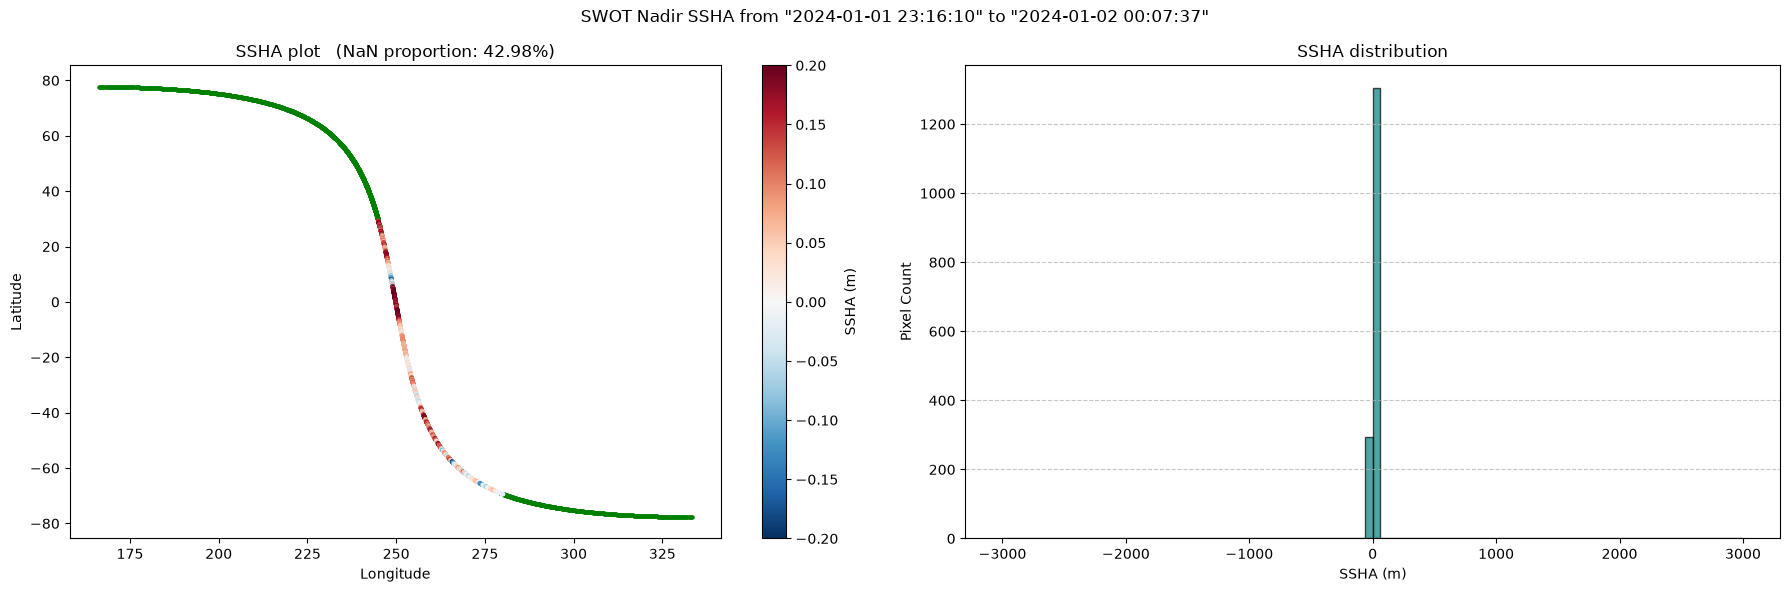

In [ ]:
ssha_nadir = open_half_orbit('nadir', 'SWOT_GPR_2PfP008_524_20240101_231610_20240102_000737.nc')

display_nadir(ssha_nadir)

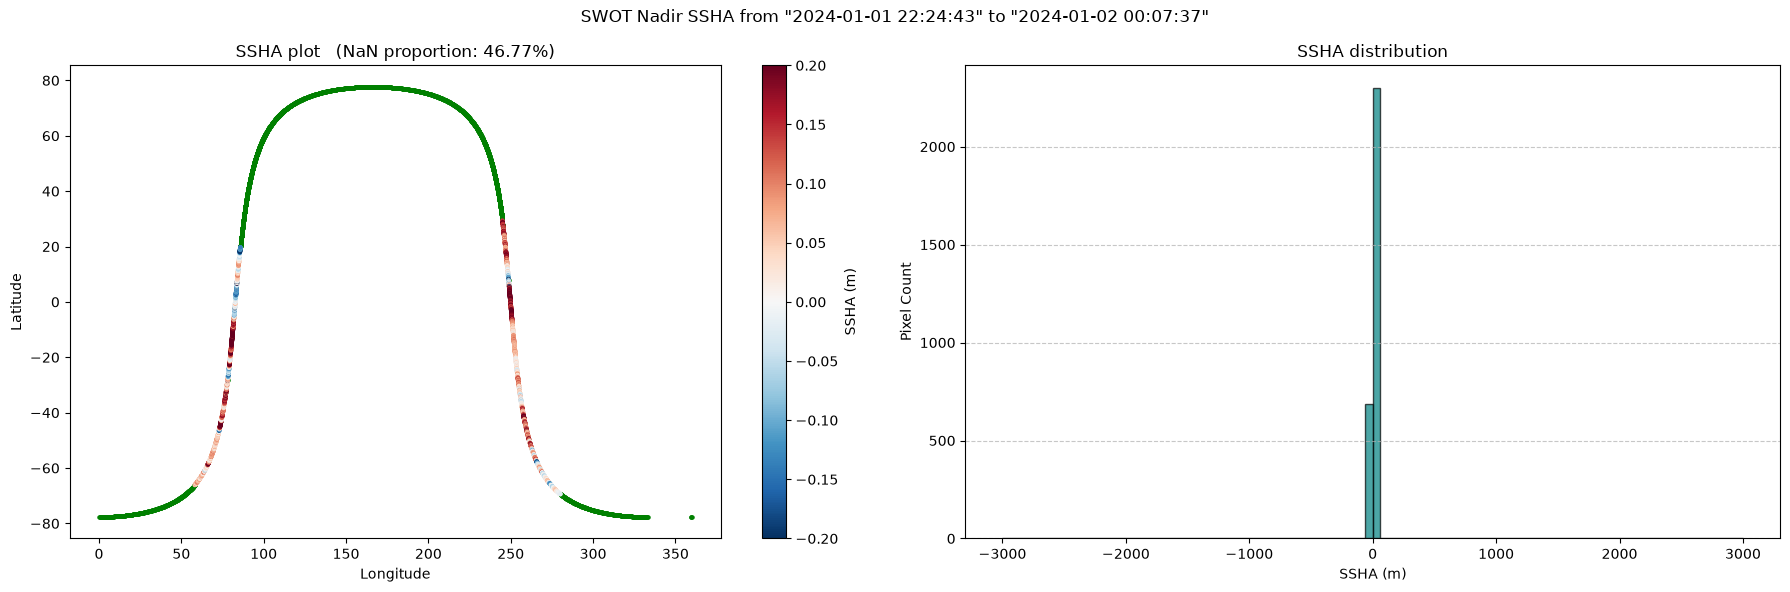

In [ ]:
ssha1 = open_half_orbit('nadir', 'SWOT_GPR_2PfP008_524_20240101_231610_20240102_000737.nc')
ssha2 = open_half_orbit('nadir', 'SWOT_GPR_2PfP008_523_20240101_222443_20240101_231610.nc')

ssha_combined = xr.concat([ssha1, ssha2], dim='time').sortby('time')

display_nadir(ssha_combined)

## Karin

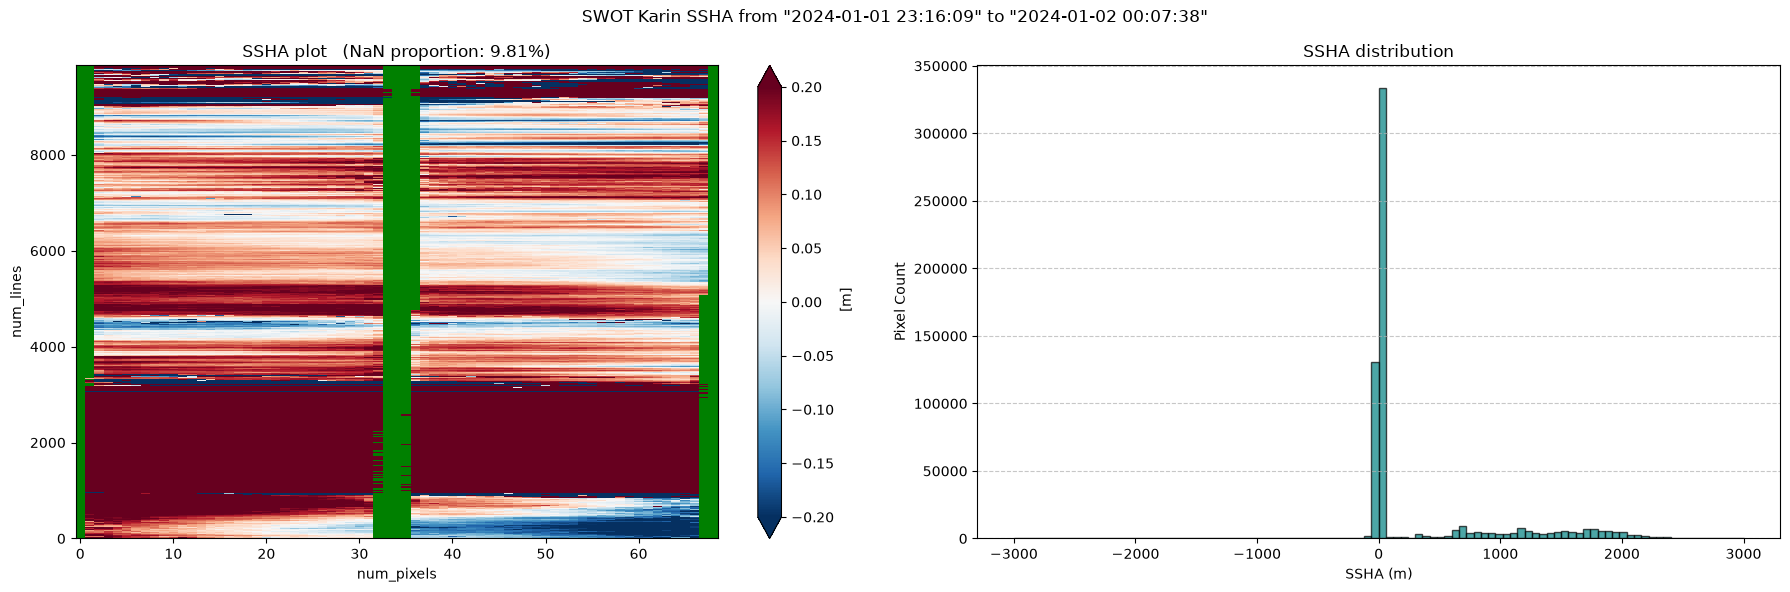

In [ ]:
ssha_karin = open_half_orbit('karin', 'SWOT_L2_LR_SSH_Expert_008_524_20240101T231609_20240102T000738_PGD0_02.nc')

display_karin(ssha_karin)

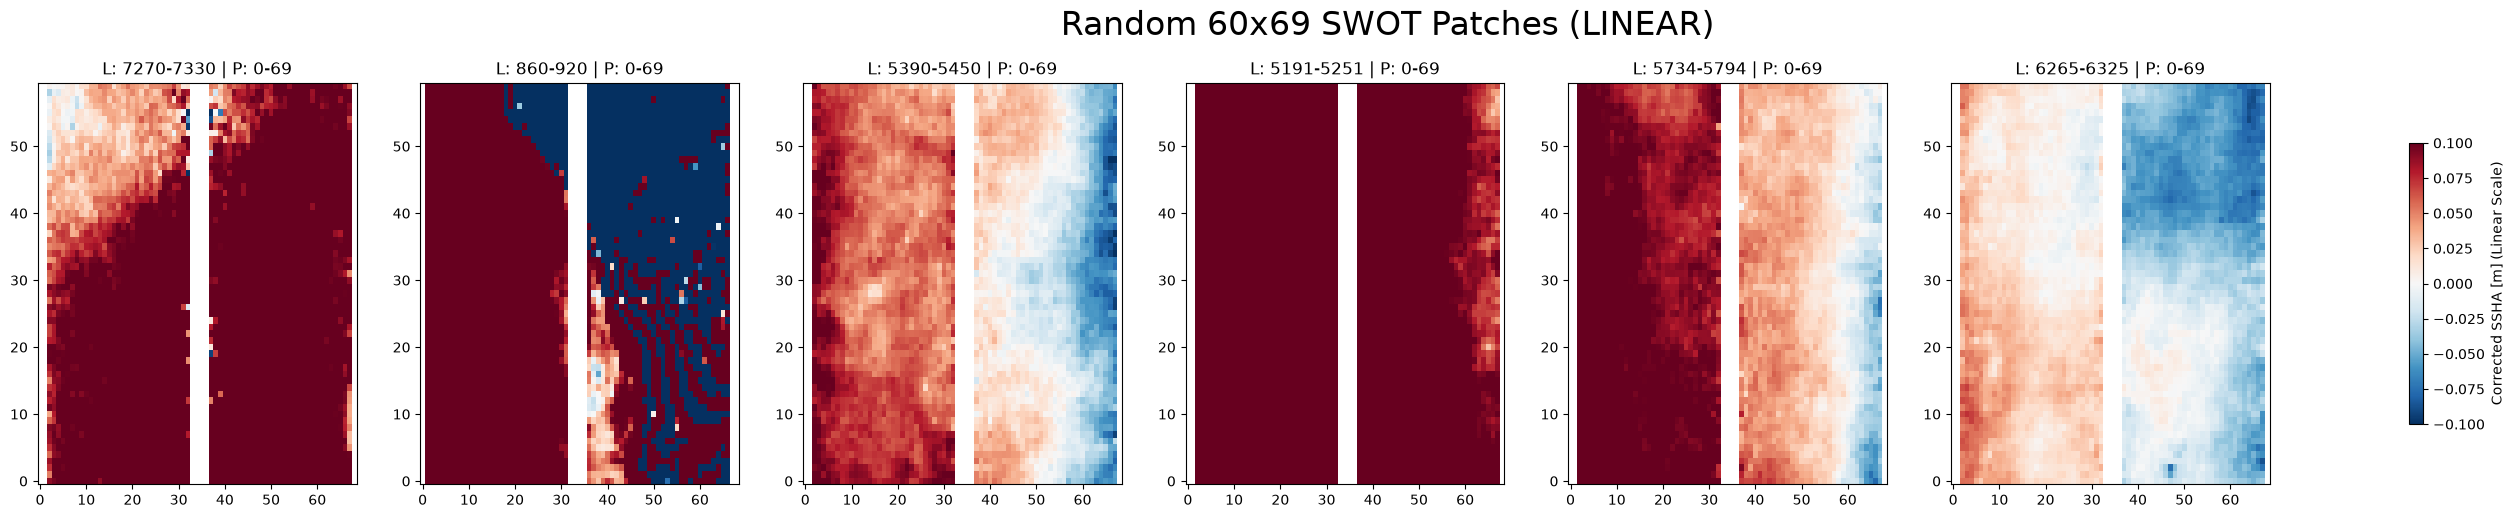

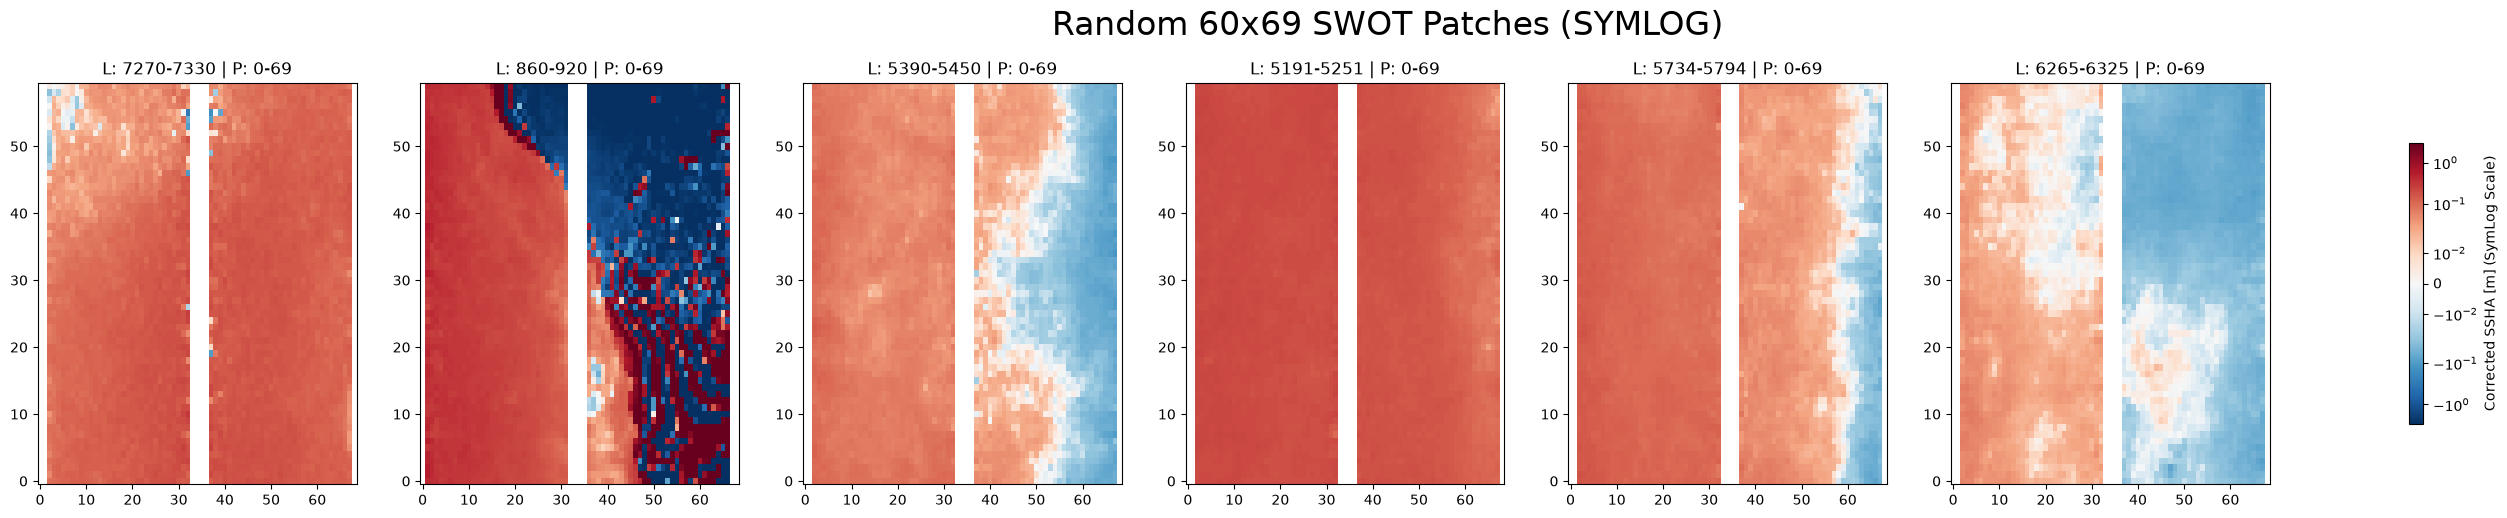

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

# --- Toggles ---
display_linear = True
display_log = True
# ---------------

x_rows = 1
y_cols = 6
patch_height = 60
patch_width = ssha_karin.sizes['num_pixels']
removal_threshold = 1

lin_vmax = 0.1
log_vmax = 3
linthresh = 0.015

np.random.seed(42)

max_lines = ssha_karin.sizes['num_lines'] - patch_height
num_patches = x_rows * y_cols

# 1. Pre-calculate the random starting lines so both plots use the exact same data
valid_start_lines = []
while len(valid_start_lines) < num_patches:
    start_line = np.random.randint(0, max_lines)
    
    # Grab a sample pixel to check if it's land/ice/out of bounds
    first_pixel = ssha_karin.isel(num_lines=start_line, num_pixels=15).values
    
    if first_pixel > removal_threshold or first_pixel < -removal_threshold or np.isnan(first_pixel):
        continue
        
    valid_start_lines.append(start_line)

# 2. Display the Linear Representation
if display_linear:
    fig_lin, axes_lin = plt.subplots(x_rows, y_cols, figsize=(y_cols * 6, x_rows * 6 * patch_height/patch_width))
    axes_lin = np.atleast_1d(axes_lin).flatten()
    im_lin = None

    for ax, start_line in zip(axes_lin, valid_start_lines):
        random_patch = ssha_karin.isel(
            num_lines=slice(start_line, start_line + patch_height),
            num_pixels=slice(0, patch_width)
        )
        
        im_lin = random_patch.plot(
            ax=ax, 
            cmap='RdBu_r',
            vmin=-lin_vmax, 
            vmax=lin_vmax, 
            add_colorbar=False
        )
        
        ax.set_title(f'L: {start_line}-{start_line + patch_height} | P: {0}-{patch_width}', fontsize=2 * y_cols)
        ax.set_xlabel('')
        ax.set_ylabel('')

    cbar_lin = fig_lin.colorbar(im_lin, ax=axes_lin.tolist(), shrink=0.7, label='Corrected SSHA [m] (Linear Scale)')
    plt.suptitle(f'Random {patch_height}x{patch_width} SWOT Patches (LINEAR)', fontsize=4 * y_cols, y=1.02)
    plt.show()

# 3. Display the Logarithmic Representation
if display_log:
    fig_log, axes_log = plt.subplots(x_rows, y_cols, figsize=(y_cols * 6, x_rows * 6 * patch_height/patch_width))
    axes_log = np.atleast_1d(axes_log).flatten()
    im_log = None

    for ax, start_line in zip(axes_log, valid_start_lines):
        random_patch = ssha_karin.isel(
            num_lines=slice(start_line, start_line + patch_height),
            num_pixels=slice(0, patch_width)
        )
        
        im_log = random_patch.plot(
            ax=ax, 
            cmap='RdBu_r',
            norm=SymLogNorm(linthresh=linthresh, vmin=-log_vmax, vmax=log_vmax, base=10),
            add_colorbar=False
        )
        
        ax.set_title(f'L: {start_line}-{start_line + patch_height} | P: {0}-{patch_width}', fontsize=2 * y_cols)
        ax.set_xlabel('')
        ax.set_ylabel('')

    cbar_log = fig_log.colorbar(im_log, ax=axes_log.tolist(), shrink=0.7, label='Corrected SSHA [m] (SymLog Scale)')
    plt.suptitle(f'Random {patch_height}x{patch_width} SWOT Patches (SYMLOG)', fontsize=4 * y_cols, y=1.02)
    plt.show()

c:\Users\pesen\Documents\UCL Masters Coursework\Masters Project SWOT\swot_env\Lib\site-packages\cartopy\mpl\geoaxes.py:1762: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)


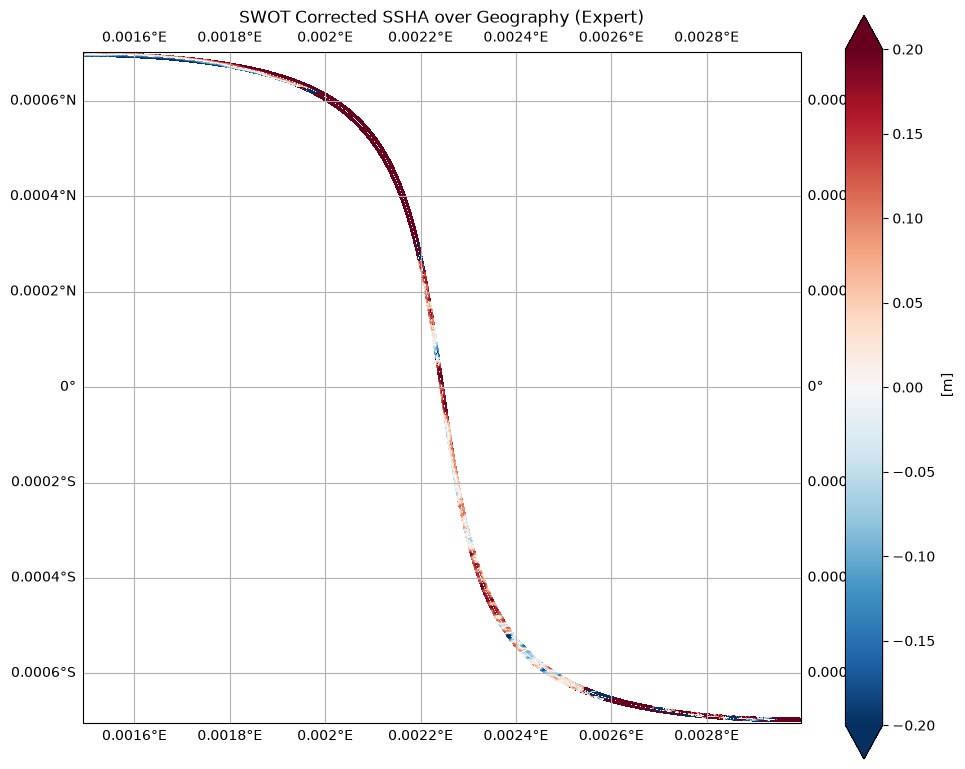

In [83]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Create an axis with a standard map projection
ax = plt.axes(projection=ccrs.Orthographic())
ax.coastlines() # Draws the continents!
ax.gridlines(draw_labels=True)

# Tell Xarray to use lon/lat for the X/Y axes instead of the matrix indices.
# We use pcolormesh for 2D curvilinear grids.
ssha_karin.plot.pcolormesh(
    ax=ax, 
    x='longitude', 
    y='latitude', 
    transform=ccrs.Orthographic(),
    cmap='RdBu_r', 
    vmin=-0.2, 
    vmax=0.2
)

plt.title('SWOT Corrected SSHA over Geography (Expert)')
plt.tight_layout()
plt.show()

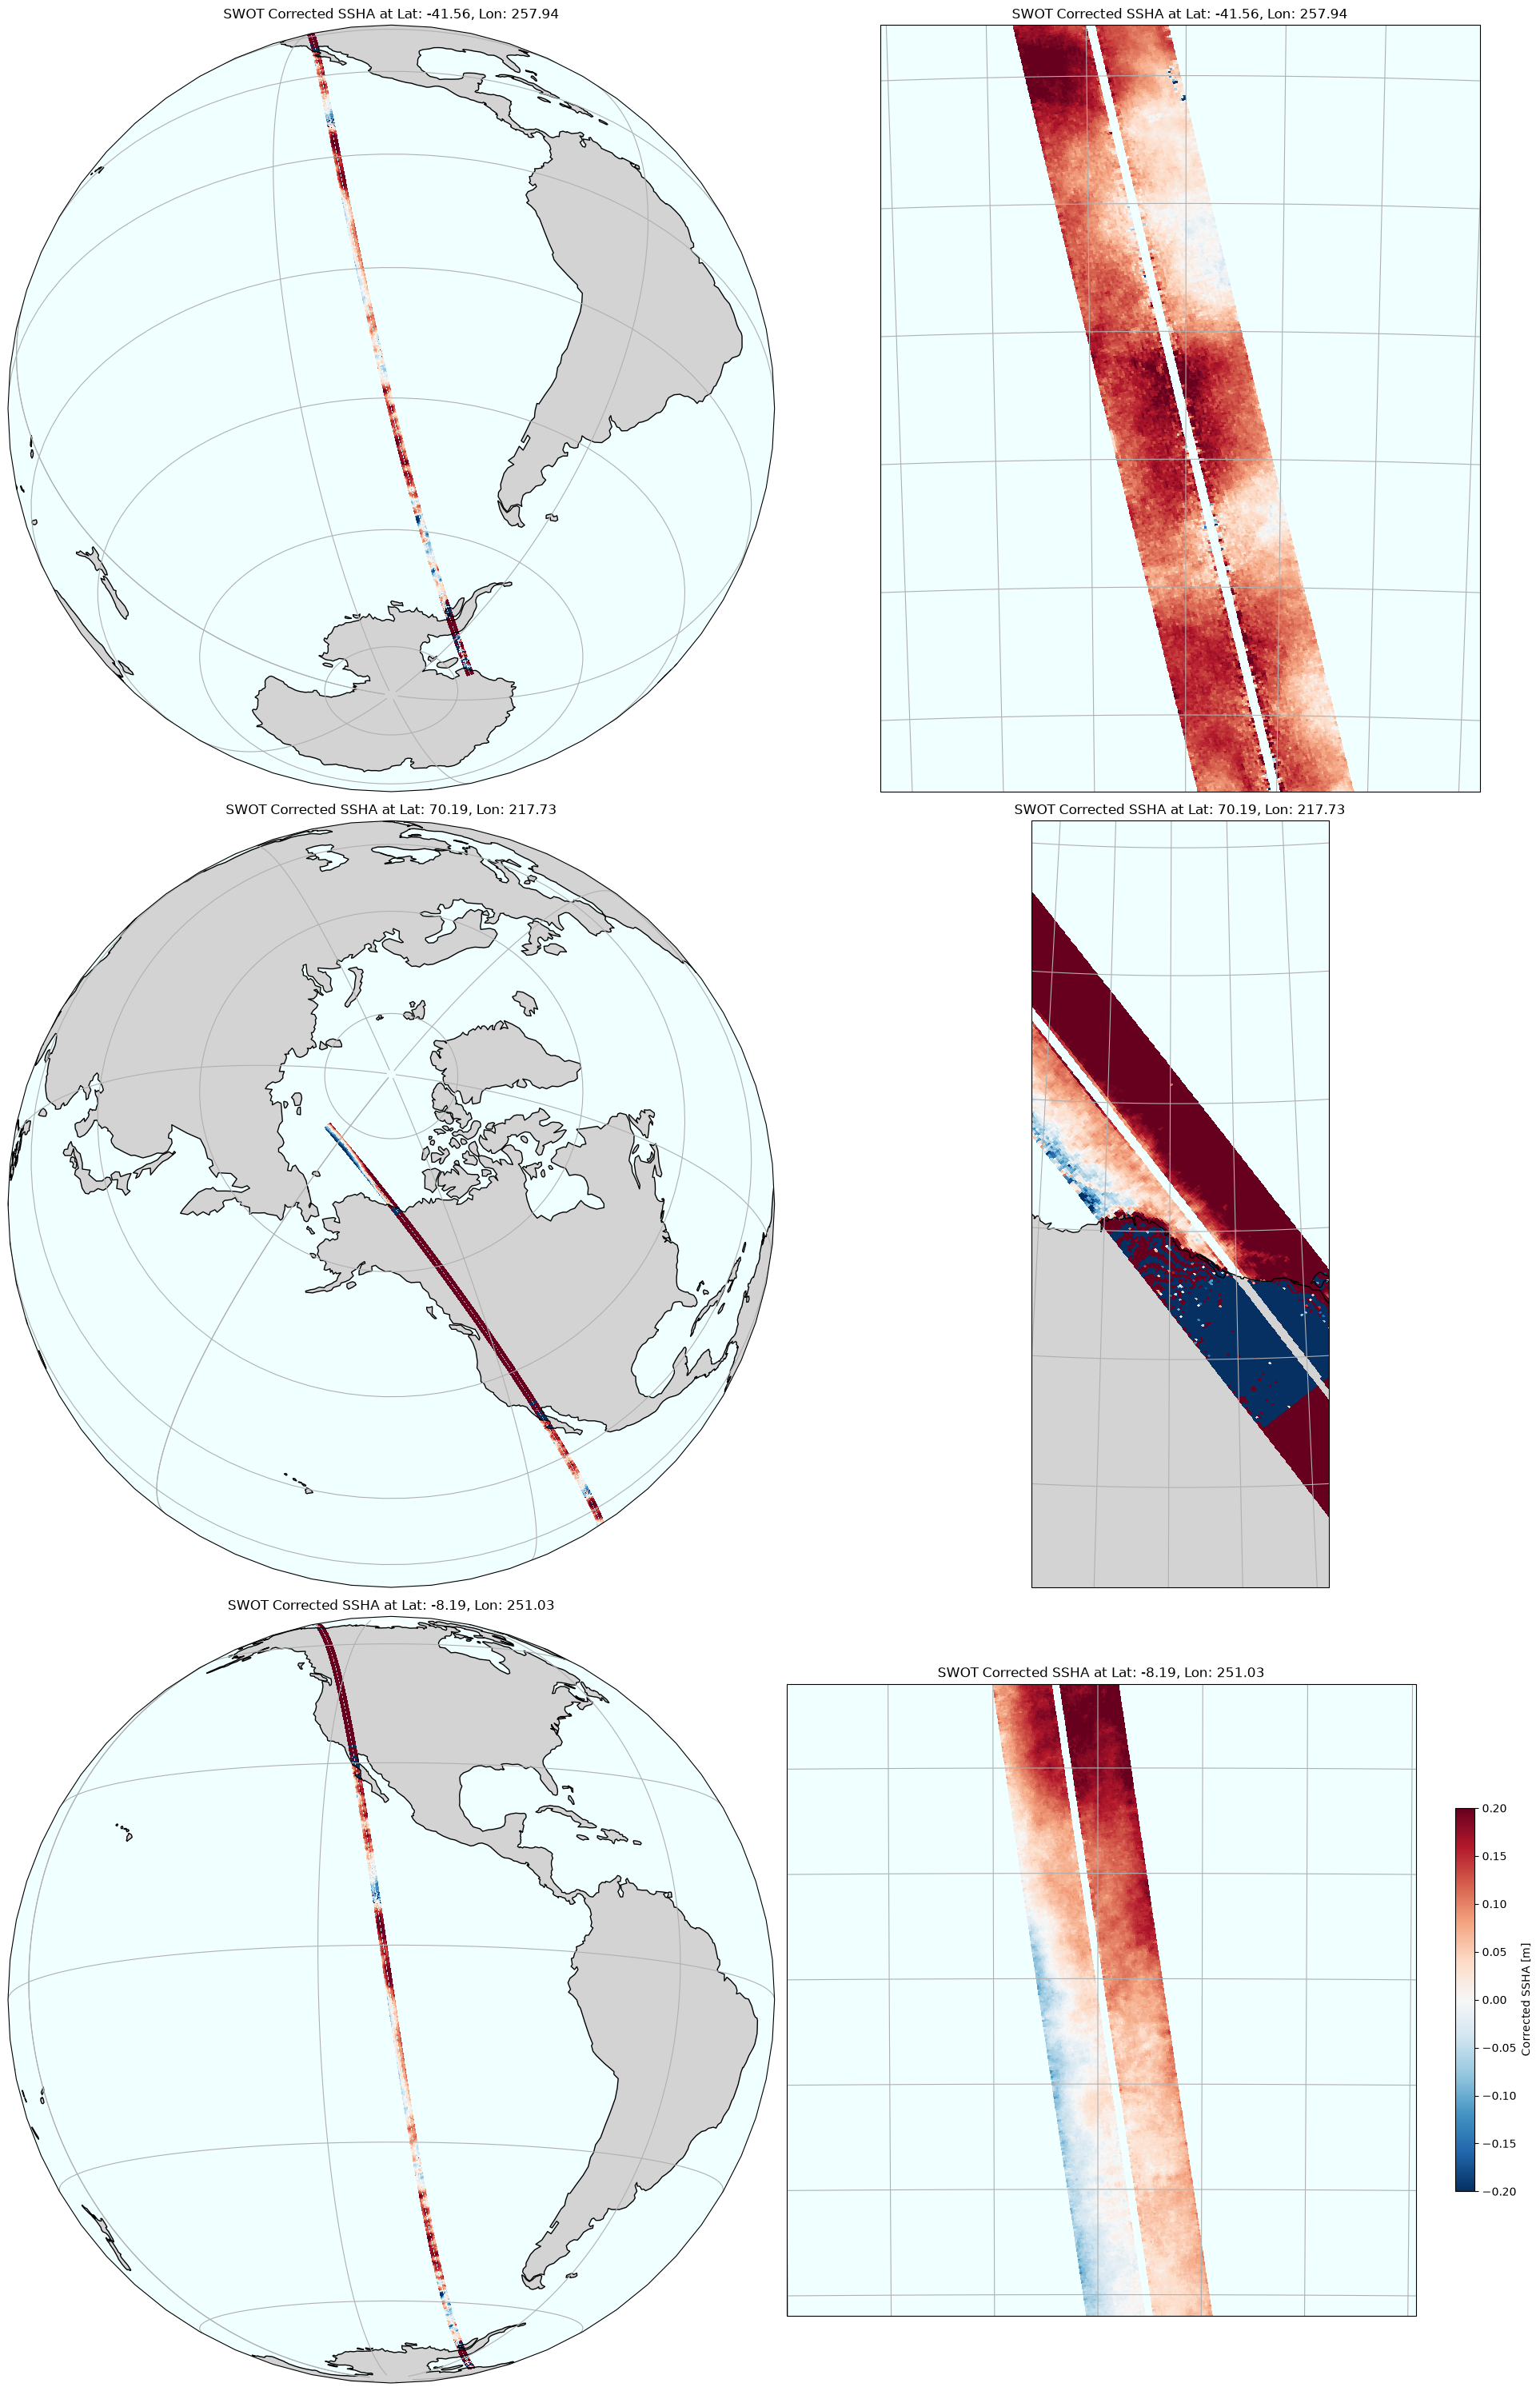

In [38]:
no_rows = 3

central_longitude = -90.0
central_latitude = 20.0
bbox_left = 3
bbox_up = 3
vmax = 0.2

np.random.seed(42)

max_lines = ssha_karin.sizes['num_lines']

fig = plt.figure(figsize=(20, 10 * no_rows))

for row in range(no_rows):

    chosen_line = np.random.randint(0, max_lines)
    lat = lat_karin['latitude'].isel(num_lines=chosen_line, num_pixels=35).values.item()
    lon = lon_karin['longitude'].isel(num_lines=chosen_line, num_pixels=35).values.item()
    #print(f"Random Pixel Location: Latitude: {lat:.2f}, Longitude: {lon:.2f}")

    for col in (1,2):

        plot_index = (row * 2) + col
        
        ax = fig.add_subplot(no_rows, 2, plot_index, projection=ccrs.Orthographic(central_longitude=lon, central_latitude=lat))

        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='azure')
        ax.coastlines()
        ax.gridlines()
        if col == 1:
            ax.set_global()
        else:
            ax.set_extent([lon - bbox_left, lon + bbox_left, lat - bbox_up, lat + bbox_up], crs=ccrs.PlateCarree()) # Zoom in 

        im = ax.pcolormesh(
            lon_karin, 
            lat_karin, 
            ssha_karin,          
            transform=ccrs.PlateCarree(), 
            cmap='RdBu_r', 
            vmin=-vmax, 
            vmax=vmax
        )

        ax.set_title(f'SWOT Corrected SSHA at Lat: {lat:.2f}, Lon: {lon:.2f}')
        
plt.colorbar(im, label='Corrected SSHA [m]', shrink=0.5)
    

plt.tight_layout()
plt.show()

## Karin and Nadir plot on globe

KaRIn Timespan: 2024-01-01 23:16:09 to 2024-01-02 00:07:38
Nadir Timespan: 2024-01-01 23:16:10 to 2024-01-02 00:07:37


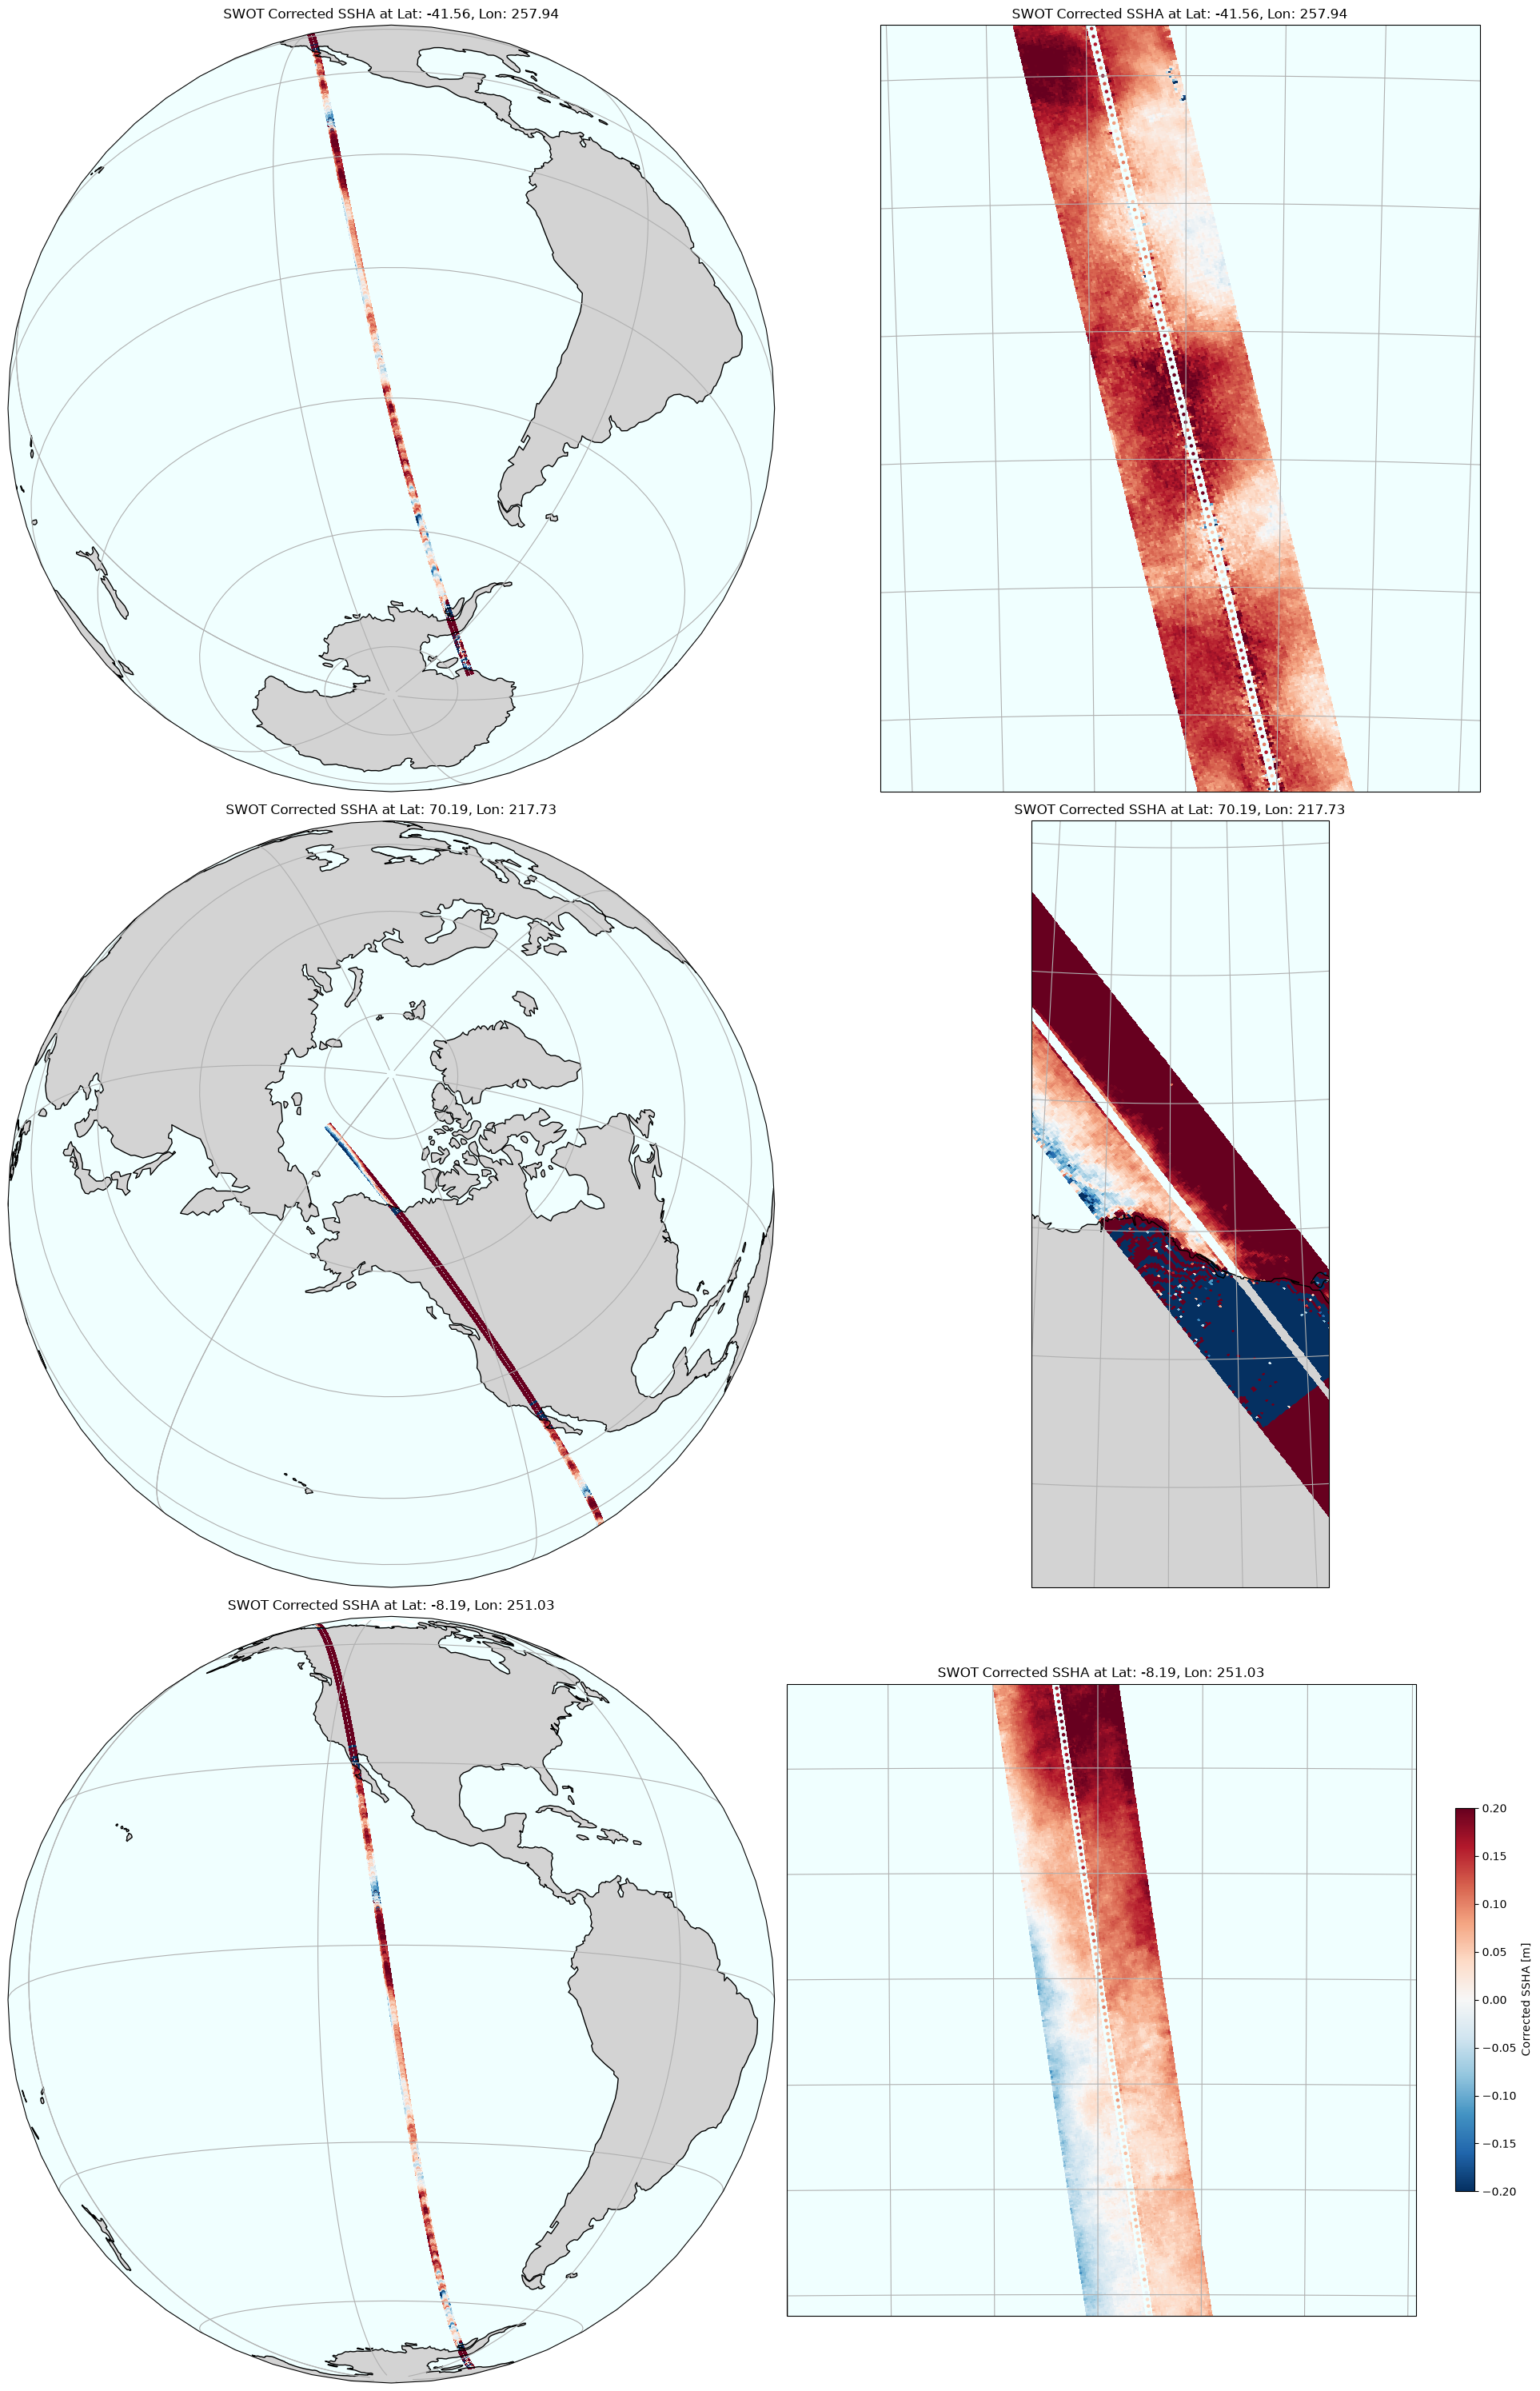

In [40]:
t_min_karin = pd.to_datetime(time_karin.min().values).strftime('%Y-%m-%d %H:%M:%S')
t_max_karin = pd.to_datetime(time_karin.max().values).strftime('%Y-%m-%d %H:%M:%S')
t_min_nadir = pd.to_datetime(time_nadir.min().values).strftime('%Y-%m-%d %H:%M:%S')
t_max_nadir = pd.to_datetime(time_nadir.max().values).strftime('%Y-%m-%d %H:%M:%S')

print(f"KaRIn Timespan: {t_min_karin} to {t_max_karin}")
print(f"Nadir Timespan: {t_min_nadir} to {t_max_nadir}")

no_rows = 3
central_longitude = -90.0
central_latitude = 20.0
bbox_left = 3
bbox_up = 3
vmax = 0.2

np.random.seed(42)
max_lines = ssha_karin.sizes['num_lines']
fig = plt.figure(figsize=(20, 10 * no_rows))

for row in range(no_rows):
    chosen_line = np.random.randint(0, max_lines)
    lat = lat_karin.isel(num_lines=chosen_line, num_pixels=35).values.item()
    lon = lon_karin.isel(num_lines=chosen_line, num_pixels=35).values.item()

    for col in (1, 2):
        plot_index = (row * 2) + col
        ax = fig.add_subplot(no_rows, 2, plot_index, projection=ccrs.Orthographic(central_longitude=lon, central_latitude=lat))

        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='azure')
        ax.coastlines()
        ax.gridlines()
        
        if col == 1:
            ax.set_global()
        else:
            ax.set_extent([lon - bbox_left, lon + bbox_left, lat - bbox_up, lat + bbox_up], crs=ccrs.PlateCarree()) 

        im = ax.pcolormesh(
            lon_karin, 
            lat_karin, 
            ssha_karin,          
            transform=ccrs.PlateCarree(), 
            cmap='RdBu_r', 
            vmin=-vmax, 
            vmax=vmax
        )

        ax.scatter(
            lon_nadir, 
            lat_nadir, 
            c=ssha_nadir, 
            transform=ccrs.PlateCarree(), 
            cmap='RdBu_r', 
            vmin=-vmax, 
            vmax=vmax,
            s=5
        )

        ax.set_title(f'SWOT Corrected SSHA at Lat: {lat:.2f}, Lon: {lon:.2f}')

#fig.colorbar(im, ax=fig.axes, label='Corrected SSHA [m]', shrink=0.5)
plt.colorbar(im, label='Corrected SSHA [m]', shrink=0.5)


plt.tight_layout()
plt.show()